# Data Preprocessing (Task - 7)

1. Load, analyse and understand the dataset using data visualisation.
2. Handle missing data
3. Handle outliers
4. Feature encoding for categorical data
5. Feature scaling
6. Split the preprocessed dataset into training and testing 

### Importing Libraries

In [1]:
# if you get an error here, please try importing all the modules first
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns

### Part 1:
This code is pre-processing the data to suit the needs for making a rainfall prediction model.

In [2]:
dataset = pd.read_csv("weather_data.csv")
df = pd.DataFrame(dataset)
df # to get the entire table


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [3]:
df.info() # to get a general information on the table

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


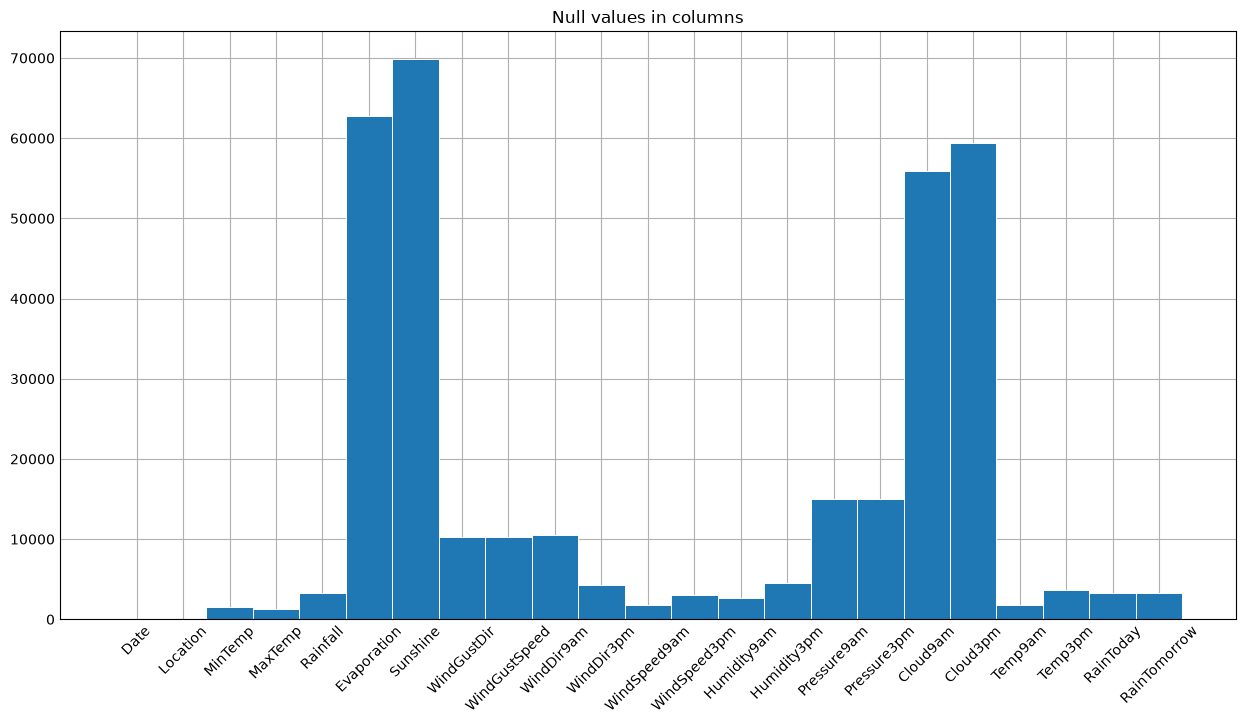

In [4]:
plt.style.use('_mpl-gallery')
x = df.isnull().sum().tolist()
fig, ax = plt.subplots(figsize=(12,6))
plt.xticks(rotation=45)
ax.bar(df.columns,x, width=1, edgecolor="white", linewidth=0.7)
plt.title("Null values in columns")
plt.show() # to get the number of null values in a column

Due to a large number of null values, Columns like evaporation, sunshine, cloud 9am and cloud 3pm is dropped

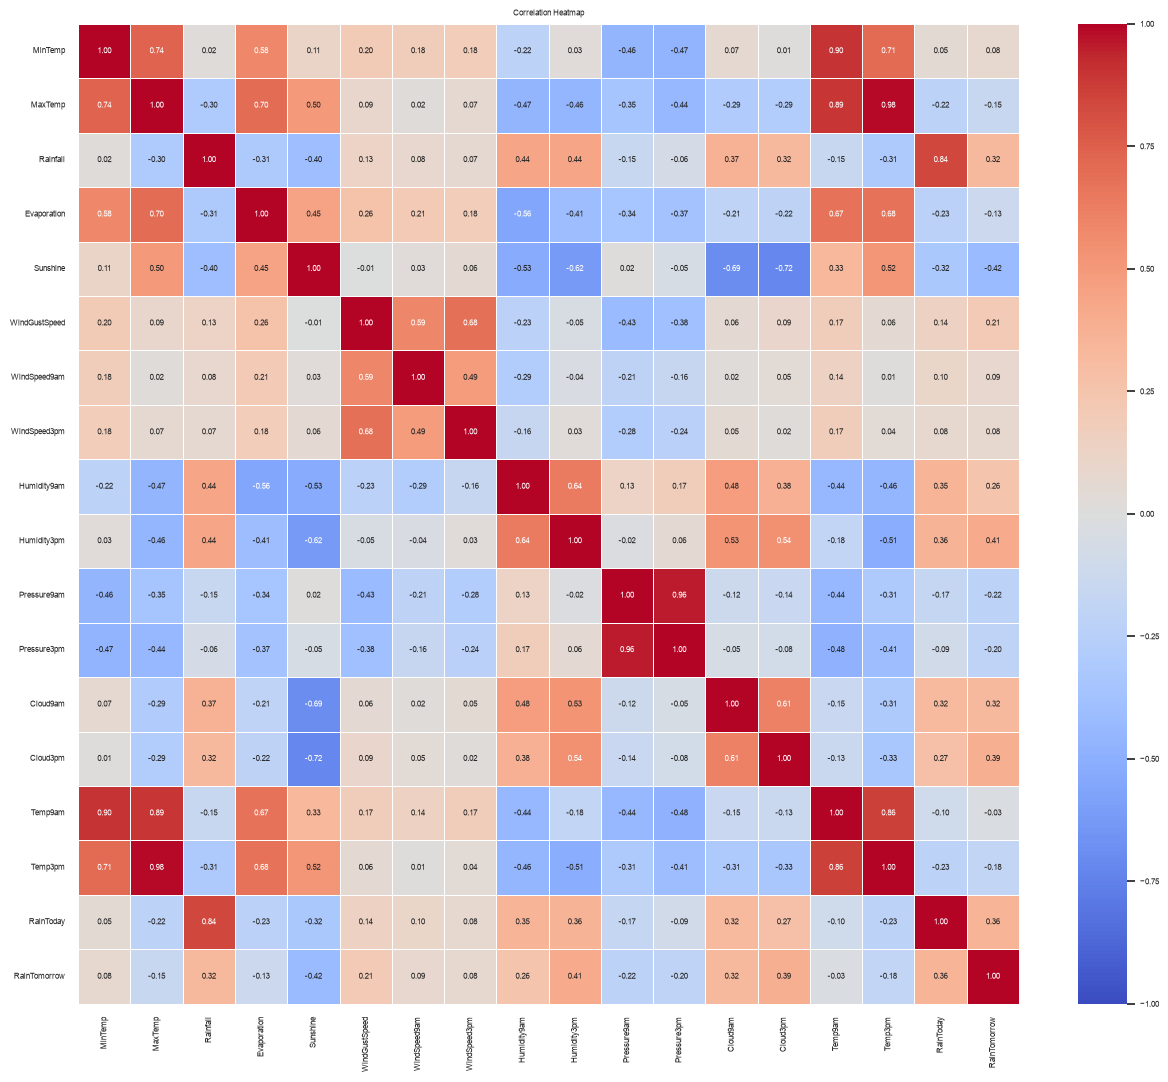

In [5]:
# to get the corellation table
le = LabelEncoder()
dfcorr = df.copy()

dfcorr["RainToday"] = le.fit_transform(df["RainToday"])
dfcorr["RainTomorrow"] = le.fit_transform(df["RainTomorrow"])

plt.figure(figsize=(12, 10))

sns.set_theme(font_scale=0.5)
dfcorr = dfcorr.corr(method='spearman', numeric_only=True)
sns.heatmap(dfcorr, vmin=-1, vmax=1, center=0,cmap="coolwarm",
            annot=True,fmt=".2f", linewidths=0.5 )
plt.title("Correlation Heatmap")
plt.show()

In [6]:
places = df["Location"].unique().tolist()
places

['Albury',
 'BadgerysCreek',
 'Cobar',
 'CoffsHarbour',
 'Moree',
 'Newcastle',
 'NorahHead',
 'NorfolkIsland',
 'Penrith',
 'Richmond',
 'Sydney',
 'SydneyAirport',
 'WaggaWagga',
 'Williamtown',
 'Wollongong',
 'Canberra',
 'Tuggeranong',
 'MountGinini',
 'Ballarat',
 'Bendigo',
 'Sale',
 'MelbourneAirport',
 'Melbourne',
 'Mildura',
 'Nhil',
 'Portland',
 'Watsonia',
 'Dartmoor',
 'Brisbane',
 'Cairns',
 'GoldCoast',
 'Townsville',
 'Adelaide',
 'MountGambier',
 'Nuriootpa',
 'Woomera',
 'Albany',
 'Witchcliffe',
 'PearceRAAF',
 'PerthAirport',
 'Perth',
 'SalmonGums',
 'Walpole',
 'Hobart',
 'Launceston',
 'AliceSprings',
 'Darwin',
 'Katherine',
 'Uluru']

### Part 2
To remove Empty rows

In [7]:
print("Before removing null values:\n\n", df.isnull().sum()) # original empty data
df1 = df.copy()
df1.dropna(subset=['RainTomorrow','RainToday'], inplace = True) # data after removing empty Rain Data
print("\n\nAfter removing rows with empty rain data: \n", df1.isnull().sum())
# data after removing large amount of empty data in columns
df1.drop(columns=['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm'], inplace=True)
print("\n\nAfter removing columns with large empty data: \n", df1.isnull().sum())
for i in places:
    median_val = df1.loc[df1["Location"] == i].median(numeric_only=True)
    try:
        median_val.fillna(df1.loc[(df1["Location"] == places[places.index(i)-1]) | (df1["Location"] == places[places.index(i)+1])].median(numeric_only=True), inplace=True) 
    except:
            median_val.fillna(df1.loc[(df1["Location"] == places[places.index(i)-1])].median(numeric_only=True), inplace=True) 
    df1.loc[df1["Location"] == i] = df1.loc[df1["Location"] == i].fillna(median_val)
for i in places:
    mode_val = df1.loc[df1["Location"] == i].mode().iloc[0]
    try:
        mode_val.fillna(df1.loc[(df1["Location"] == places[places.index(i)-1]) | (df1["Location"] == places[places.index(i)+1])].mode().iloc[0], inplace=True) 
    except:
        mode_val.fillna(df1.loc[(df1["Location"] == places[places.index(i)-1])].mode().iloc[0], inplace=True) 
    df1.loc[df1["Location"] == i] = df1.loc[df1["Location"] == i].fillna(mode_val)
print("\n\nAfter filling with the median and mode for each place:\n\n", df1.isnull().sum())

Before removing null values:

 Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64


After removing rows with empty rain data: 
 Date                 0
Location             0
MinTemp            468
MaxTemp            307
Rainfall             0
Evaporation      59694
Sunshine         66805
WindGustDir       9163
WindGustSpeed     9105
WindDir9am        9660
WindDir3pm        3670
WindSpeed9am      1055
WindSpeed3pm      2531
Humidity9am       1517
Humidity3pm       3501
Pressure9am      13743
Pressure3pm  

In [8]:
df1.info() # data after having non zero values
print("\n\n\n")
df1

<class 'pandas.DataFrame'>
Index: 140787 entries, 0 to 145458
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           140787 non-null  str    
 1   Location       140787 non-null  str    
 2   MinTemp        140787 non-null  float64
 3   MaxTemp        140787 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   WindGustDir    140787 non-null  str    
 6   WindGustSpeed  140787 non-null  float64
 7   WindDir9am     140787 non-null  str    
 8   WindDir3pm     140787 non-null  str    
 9   WindSpeed9am   140787 non-null  float64
 10  WindSpeed3pm   140787 non-null  float64
 11  Humidity9am    140787 non-null  float64
 12  Humidity3pm    140787 non-null  float64
 13  Pressure9am    140787 non-null  float64
 14  Pressure3pm    140787 non-null  float64
 15  Temp9am        140787 non-null  float64
 16  Temp3pm        140787 non-null  float64
 17  RainToday      140787 non-null  str    
 18  

,Date,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,2017-06-20,Uluru,3.5,21.8,0.0,E,31.0,ESE,E,15.0,13.0,59.0,27.0,1024.7,1021.2,9.4,20.9,No,No
145455,2017-06-21,Uluru,2.8,23.4,0.0,E,31.0,SE,ENE,13.0,11.0,51.0,24.0,1024.6,1020.3,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NNW,22.0,SE,N,13.0,9.0,56.0,21.0,1023.5,1019.1,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,N,37.0,SE,WNW,9.0,9.0,53.0,24.0,1021.0,1016.8,12.5,26.1,No,No


### Part 3

In [9]:
numeric_df = df1.select_dtypes(include=['number'])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

df1 = df1[~((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]
df1.info()

<class 'pandas.DataFrame'>
Index: 107329 entries, 0 to 145458
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           107329 non-null  str    
 1   Location       107329 non-null  str    
 2   MinTemp        107329 non-null  float64
 3   MaxTemp        107329 non-null  float64
 4   Rainfall       107329 non-null  float64
 5   WindGustDir    107329 non-null  str    
 6   WindGustSpeed  107329 non-null  float64
 7   WindDir9am     107329 non-null  str    
 8   WindDir3pm     107329 non-null  str    
 9   WindSpeed9am   107329 non-null  float64
 10  WindSpeed3pm   107329 non-null  float64
 11  Humidity9am    107329 non-null  float64
 12  Humidity3pm    107329 non-null  float64
 13  Pressure9am    107329 non-null  float64
 14  Pressure3pm    107329 non-null  float64
 15  Temp9am        107329 non-null  float64
 16  Temp3pm        107329 non-null  float64
 17  RainToday      107329 non-null  str    
 18  

### Part 4

In [10]:
df1["RainToday"] = le.fit_transform(df1["RainToday"])
df1["RainTomorrow"] = le.fit_transform(df1["RainTomorrow"])
df1['Date'] = pd.to_datetime(df1['Date'])
df1['Year'] = df1['Date'].dt.year
df1['Month'] = df1['Date'].dt.month
df1['Day'] = df1['Date'].dt.day
df1.drop(columns=['Date'], inplace=True)
compass_angles = {
    "N": 0.0,
    "NNE": 22.5,
    "NE": 45.0,
    "ENE": 67.5,
    "E": 90.0,
    "ESE": 112.5,
    "SE": 135.0,
    "SSE": 157.5,
    "S": 180.0,
    "SSW": 202.5,
    "SW": 225.0,
    "WSW": 247.5,
    "W": 270.0,
    "WNW": 292.5,
    "NW": 315.0,
    "NNW": 337.5
}
df1['WindGustDir'] = df1['WindGustDir'].map(compass_angles)
df1['WindDir9am'] = df1['WindDir9am'].map(compass_angles)
df1['WindDir3pm'] = df1['WindDir3pm'].map(compass_angles)

df1 = pd.get_dummies(df1, dtype=int)

In [11]:
df1.info()
df1

<class 'pandas.DataFrame'>
Index: 107329 entries, 0 to 145458
Data columns (total 69 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   MinTemp                    107329 non-null  float64
 1   MaxTemp                    107329 non-null  float64
 2   Rainfall                   107329 non-null  float64
 3   WindGustDir                107329 non-null  float64
 4   WindGustSpeed              107329 non-null  float64
 5   WindDir9am                 107329 non-null  float64
 6   WindDir3pm                 107329 non-null  float64
 7   WindSpeed9am               107329 non-null  float64
 8   WindSpeed3pm               107329 non-null  float64
 9   Humidity9am                107329 non-null  float64
 10  Humidity3pm                107329 non-null  float64
 11  Pressure9am                107329 non-null  float64
 12  Pressure3pm                107329 non-null  float64
 13  Temp9am                    107329 non-null  f

,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,...,Location_Townsville,Location_Tuggeranong,Location_Uluru,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera
0,13.4,22.9,0.6,270.0,44.0,270.0,292.5,20.0,24.0,71.0,...,0,0,0,0,0,0,0,0,0,0
1,7.4,25.1,0.0,292.5,44.0,337.5,247.5,4.0,22.0,44.0,...,0,0,0,0,0,0,0,0,0,0
2,12.9,25.7,0.0,247.5,46.0,270.0,247.5,19.0,26.0,38.0,...,0,0,0,0,0,0,0,0,0,0
3,9.2,28.0,0.0,45.0,24.0,135.0,90.0,11.0,9.0,45.0,...,0,0,0,0,0,0,0,0,0,0
4,17.5,32.3,1.0,270.0,41.0,67.5,315.0,7.0,20.0,82.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,3.5,21.8,0.0,90.0,31.0,112.5,90.0,15.0,13.0,59.0,...,0,0,1,0,0,0,0,0,0,0
145455,2.8,23.4,0.0,90.0,31.0,135.0,67.5,13.0,11.0,51.0,...,0,0,1,0,0,0,0,0,0,0
145456,3.6,25.3,0.0,337.5,22.0,135.0,0.0,13.0,9.0,56.0,...,0,0,1,0,0,0,0,0,0,0
145457,5.4,26.9,0.0,0.0,37.0,135.0,292.5,9.0,9.0,53.0,...,0,0,1,0,0,0,0,0,0,0


### Part 5

In [12]:
sta = StandardScaler()
df1 = pd.DataFrame(sta.fit_transform(df1))
df1

,0,1,2,3,4,5,6,7,8,9,...,59,60,61,62,63,64,65,66,67,68
0,0.225664,-0.136762,1.146077,1.069659,0.610600,1.039894,1.255047,0.897574,0.821516,0.231048,...,-0.156535,-0.151527,-0.106558,-0.151205,-0.137657,-0.146695,-0.126711,-0.143785,-0.137305,-0.150979
1,-0.713583,0.189014,-0.393191,1.292076,0.610600,1.684351,0.809880,-1.129259,0.564395,-1.287621,...,-0.156535,-0.151527,-0.106558,-0.151205,-0.137657,-0.146695,-0.126711,-0.143785,-0.137305,-0.150979
2,0.147393,0.277862,-0.393191,0.847241,0.800813,1.039894,0.809880,0.770897,1.078636,-1.625103,...,-0.156535,-0.151527,-0.106558,-0.151205,-0.137657,-0.146695,-0.126711,-0.143785,-0.137305,-0.150979
3,-0.431809,0.618446,-0.393191,-1.154515,-1.291526,-0.249018,-0.748202,-0.242519,-1.106887,-1.231374,...,-0.156535,-0.151527,-0.106558,-0.151205,-0.137657,-0.146695,-0.126711,-0.143785,-0.137305,-0.150979
4,0.867483,1.255189,2.172255,1.069659,0.325281,-0.893475,1.477630,-0.749228,0.307275,0.849765,...,-0.156535,-0.151527,-0.106558,-0.151205,-0.137657,-0.146695,-0.126711,-0.143785,-0.137305,-0.150979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107324,-1.324093,-0.299650,-0.393191,-0.709680,-0.625782,-0.463837,-0.748202,0.264189,-0.592646,-0.443916,...,-0.156535,-0.151527,9.384546,-0.151205,-0.137657,-0.146695,-0.126711,-0.143785,-0.137305,-0.150979
107325,-1.433672,-0.062722,-0.393191,-0.709680,-0.625782,-0.249018,-0.970785,0.010835,-0.849766,-0.893892,...,-0.156535,-0.151527,9.384546,-0.151205,-0.137657,-0.146695,-0.126711,-0.143785,-0.137305,-0.150979
107326,-1.308439,0.218630,-0.393191,1.736911,-1.481738,-0.249018,-1.638535,0.010835,-1.106887,-0.612657,...,-0.156535,-0.151527,9.384546,-0.151205,-0.137657,-0.146695,-0.126711,-0.143785,-0.137305,-0.150979
107327,-1.026665,0.455558,-0.393191,-1.599350,-0.055144,-0.249018,1.255047,-0.495873,-1.106887,-0.781398,...,-0.156535,-0.151527,9.384546,-0.151205,-0.137657,-0.146695,-0.126711,-0.143785,-0.137305,-0.150979


### Part 6

In [13]:
result = df1.iloc[:, 16].values
data = df1.drop(df1.columns[16], axis=1).values
data_train, data_test, result_train, result_test = train_test_split(data, result, test_size = 0.2, random_state = 1)

#### The training data and results are:

In [14]:
data_train

array([[-0.8701241 , -0.69946533,  0.63298739, ..., -0.14378541,
        -0.13730514, -0.1509789 ],
       [ 0.61701675,  0.33709402,  0.11989804, ..., -0.14378541,
        -0.13730514, -0.1509789 ],
       [ 1.24318133,  0.87018168, -0.3931913 , ..., -0.14378541,
        -0.13730514, -0.1509789 ],
       ...,
       [-1.35540165, -1.46948084, -0.3931913 , ..., -0.14378541,
        -0.13730514, -0.1509789 ],
       [-0.79185353, -1.0548571 , -0.3931913 , ..., -0.14378541,
        -0.13730514,  6.62344195],
       [-1.26147696, -1.67679271, -0.3931913 , ..., -0.14378541,
        -0.13730514, -0.1509789 ]], shape=(85863, 68))

In [15]:
result_train

array([-0.42705504, -0.42705504, -0.42705504, ..., -0.42705504,
       -0.42705504, -0.42705504], shape=(85863,))

#### The testing data and results are:

In [16]:
data_test

array([[ 0.78921201,  0.76652574, -0.3931913 , ..., -0.14378541,
        -0.13730514, -0.1509789 ],
       [ 0.78921201,  0.12978215, -0.3931913 , ..., -0.14378541,
        -0.13730514, -0.1509789 ],
       [-0.38484656, -1.29178495,  0.11989804, ..., -0.14378541,
        -0.13730514, -0.1509789 ],
       ...,
       [ 0.4448215 ,  0.54440588, -0.3931913 , ..., -0.14378541,
        -0.13730514, -0.1509789 ],
       [-0.47877125, -0.53657743,  2.17225542, ..., -0.14378541,
        -0.13730514, -0.1509789 ],
       [ 0.94575316,  1.07749355, -0.3931913 , ..., -0.14378541,
        -0.13730514, -0.1509789 ]], shape=(21466, 68))

In [17]:
result_test

array([-0.42705504, -0.42705504, -0.42705504, ..., -0.42705504,
       -0.42705504, -0.42705504], shape=(21466,))

# ===============| End of File |===============